In [1]:
from astropy.table import Table 

# load data onto an astropy table

ceers_path = '/home/caltech-msanche3/data/ceers_cat_v1.0_final.fits'
ceers_data = Table.read(ceers_path)
# change units of flux from nJy to microJy so eazy fits correctly
for col in ceers_data.colnames:
    if '_FLUX' in col or '_FLUXERR_SE' in col:
        ceers_data[col] = ceers_data[col] * 0.001


In [2]:
ceers_zmed = []
ceers_hi = []
ceers_lo = []
ids_index = ids_index = [10334, 47933, 15751, 21441, 46299, 29946, 11167, 54216, 19472, 19299, 6397, 54393, 49864, 48782, 19909, 39233, 3696, 15399, 50523, 20633, 48980, 8984, 38753, 8324]
for id in ids_index:
    ceers_zmed.append(ceers_data[id]['LP_Z_MED'].item())
    ceers_hi.append(ceers_data[id]['LP_Z_MED68_HIGH'].item()-ceers_data[id]['LP_Z_MED'].item())
    ceers_lo.append(ceers_data[id]['LP_Z_MED'].item()-ceers_data[id]['LP_Z_MED68_LOW'].item())

ceers_err = [ceers_lo,ceers_hi]
ceers_zmed = [11.736116161794623, 11.480833303772885, 10.30064042924721, 10.33974217606262, 9.707642613930918, 9.05010201046042, 9.102315981781214, 9.213458781674303, 8.886823410395486, 8.908769976417343, 8.537985769984697, 8.261335542861874, 9.243047692793477, 7.48841222410888, 7.248310829332562, 8.45055173955082, 7.308088549655558, 7.218145159888755, 7.637085622391428, 7.150313252970524, 7.396003302294281, 7.185390615815184, 10.930007071546587, 10.633041101956207]
print(ceers_err)

[[0.4370939221665324, 0.411639182889461, 0.47725916660027146, 0.3041781858302688, 0.2224898089059959, 0.31544902080641, 0.09982842917251311, 0.12666111650527512, 0.049257934312619156, 0.042285681514096396, 0.025968359169958433, 0.25548593355250837, 0.44759874617661666, 0.24051642065082657, 0.1772519618993469, 0.3716114860888702, 0.1522301422924448, 0.025992328663253517, 0.008263770811625548, 0.10252849563051214, 0.02280462060398225, 0.06235253425931475, 0.30389723134156554, 10.129730870297971], [0.44994245919018816, 0.39511241062143654, 0.655127475284937, 0.27964918381541537, 0.3999923006869892, 1.668011386976989, 0.10729565417102016, 0.1084147842195442, 0.04848996891603363, 0.03358941315693187, 0.02596165128038841, 0.30914198458900444, 0.6789378743494563, 0.09713221037115716, 0.08323431564182737, 0.3254285536849064, 0.46803847299621104, 0.12856850521073593, 0.009278469098203068, 0.1308749928591677, 0.020382057695389477, 0.062399472723590144, 0.3515442148253065, 0.3029946108829442]]


In [3]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
# 52480 is a little off in coords, 16224 is too
# 20615 and 11262 are from Kasper paper
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379,52280,21065,42377,4450,16411,54045,21811,52480,9893,41878,9228]
zspec = [11.409,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.762,8.715,8.679,8.005,7.769,7.451,7.108,7.6459,7.5138,7.1751,7.0809,7.0539,7.1042,7.1832,10.7503,7.0404] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889,7.603,7.301,8.383,7.293,7.201,7.637,7.093,7.399,7.195,11.046,10.694]
print(len(ids),len(zspec),len(ceers_zphot))

24 24 24


In [4]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = ceers_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 6
params['Z_MAX'] = 12
params['IGM_SCALE_TAU'] = 1.0

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = '/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/fsps-hot/45k_mod_2/fsps_45k_mod_2.param'

# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'ceers_mod_fit_2'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/ceers_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 87345
F105W_FLUX F105W_FLUXERR_SE (202): hst/wfc3/IR/f105w.dat
F115W_FLUX F115W_FLUXERR_SE (364): jwst_nircam_f115w
F125W_FLUX F125W_FLUXERR_SE (203): hst/wfc3/IR/f125w.dat
F140W_FLUX F140W_FLUXERR_SE (204): hst/wfc3/IR/f140w.dat
F150W_FLUX F150W_FLUXERR_SE (365): jwst_nircam_f150w
F160W_FLUX F160W_FLUXERR_SE (205): hst/wfc3/IR/f160w.dat
F200W_FLUX F200W_FLUXERR_SE (366): jwst_nircam_f200w
F277W_FLUX F277W_FLUXERR_SE (375): jwst_nircam_f277w
F356W_FLUX F356W_FLUXERR_SE (376): jwst_nircam_f356w
F410M_FLUX F410M_FLUXERR_SE (383): jwst_nircam_f410m
F435W_FLUX F435W_FLUXERR_SE (233): hst/ACS_update_sep07/wfc_f435w_t81.dat
F444W_FLUX F444W_FLUXERR_SE (377): jwst_nircam_f444w
F606W_FLUX F606W_FLUXERR_SE (236): hst/ACS_update_sep07/wfc_f606w_t

100%|██████████| 12/12 [00:05<00:00,  2.04it/s]


Template   0: fsps_45k_mod_t0.1_Av0.0.mod.20.5.fits (NZ=1).
Template   1: fsps_45k_mod_t0.1_Av0.5.mod.20.5.fits (NZ=1).
Template   2: fsps_45k_mod_t0.3_Av0.0.mod.20.5.fits (NZ=1).
Template   3: fsps_45k_mod_t0.3_Av0.5.mod.20.5.fits (NZ=1).
Template   4: fsps_45k_mod_t0.5_Av0.0.mod.20.5.fits (NZ=1).
Template   5: fsps_45k_mod_t0.5_Av0.5.mod.20.5.fits (NZ=1).
Template   6: fsps_45k_mod_t0.1_Av0.0.mod.22.fits (NZ=1).
Template   7: fsps_45k_mod_t0.1_Av0.5.mod.22.fits (NZ=1).
Template   8: fsps_45k_mod_t0.3_Av0.0.mod.22.fits (NZ=1).
Template   9: fsps_45k_mod_t0.3_Av0.5.mod.22.fits (NZ=1).
Template  10: fsps_45k_mod_t0.5_Av0.0.mod.22.fits (NZ=1).
Template  11: fsps_45k_mod_t0.5_Av0.5.mod.22.fits (NZ=1).
Process templates: 7.085 s


62it [00:01, 34.17it/s]

Fitting program initialized successfully!


In [5]:
ez.set_sys_err(positive=True) 

chunk_size = 30000

total_obj = 0
# 2. Fit the 8<z objects
print('Fitting catalog in chunks...')
# total objects: 87345
# split into chunks
for i in range(0, 87345, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = ez.idx[i : i + chunk_size]
    sample = (6 <= ceers_data[i : i + chunk_size]['LP_Z_BEST']) & (ceers_data[i : i + chunk_size]['LP_Z_BEST'] <=13)
    ct = 0
    for j in sample:
        if j:
            ct+=1
    total_obj = total_obj + ct
    print('ct= ',ct)
    print("total= ",total_obj)
    ez.fit_catalog(chunk[sample],n_proc=16)

print('Catalog fitted successfully!')



Set sys_err = 0.03 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...
ct=  898
total=  898


100%|██████████| 62/62 [00:00<00:00, 157.99it/s]


Compute best fits
fit_best: 0.1 s (n_proc=1,  NOBJ=559)
Fit 0.7 s (n_proc=16, NOBJ=898)
Fitting chunk 2...
ct=  1103
total=  2001


100%|██████████| 62/62 [00:00<00:00, 123.77it/s]


Compute best fits
fit_best: 0.2 s (n_proc=1,  NOBJ=1315)
Fit 0.9 s (n_proc=16, NOBJ=1103)
Fitting chunk 3...
ct=  1705
total=  3706


100%|██████████| 62/62 [00:00<00:00, 93.09it/s] 


Compute best fits
fit_best: 0.3 s (n_proc=1,  NOBJ=2638)
Fit 1.2 s (n_proc=16, NOBJ=1705)
Catalog fitted successfully!


In [6]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=True,
    beta_prior=True, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:1136: RuntimeWarning: divide by zero encountered in log
  ln_fit_beta_y = np.log(fit_beta_y)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1540: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4014: RuntimeWarning: invalid value encountered in divide
  pzcum = (pzcum.T / pzcmax).T


fit_best: 1.3 s (n_proc=1,  NOBJ=2671)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 2671/2671 [00:08<00:00, 307.28it/s]
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4288: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


CALLED mod 2


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4323: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4653: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


[10334, 47933, 15751, 21441, 46299, 29946, 11167, 54216, 19472, 19299, 6397, 54393, 49864, 48782, 19909, 39233, 3696, 15399, 50523, 20633, 48980, 8984, 38753, 8324]


<>:71: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1517888/2786929352.py:71: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zmed[i]:.2f}",
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:2869: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
 

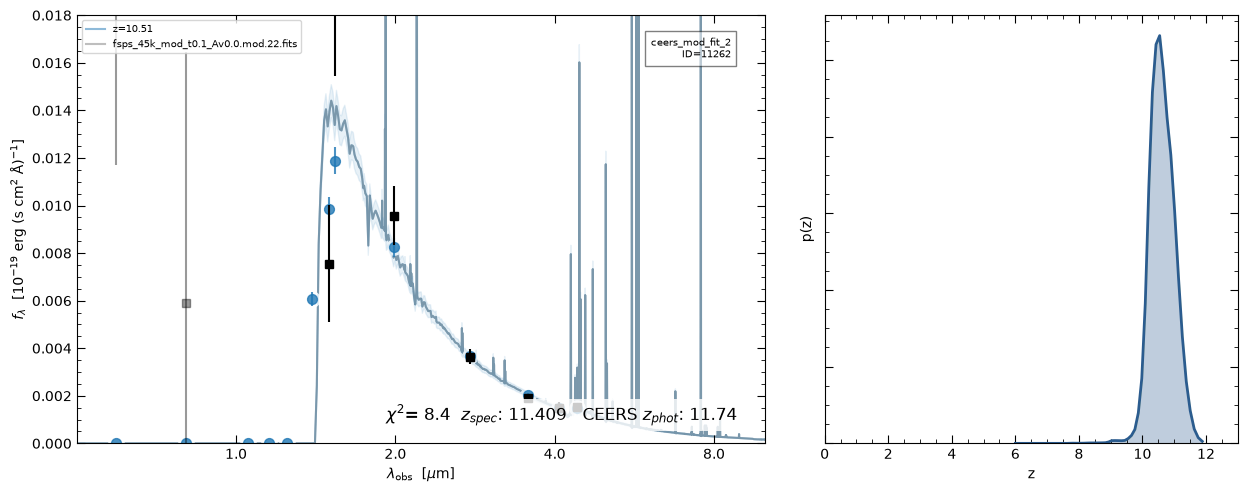

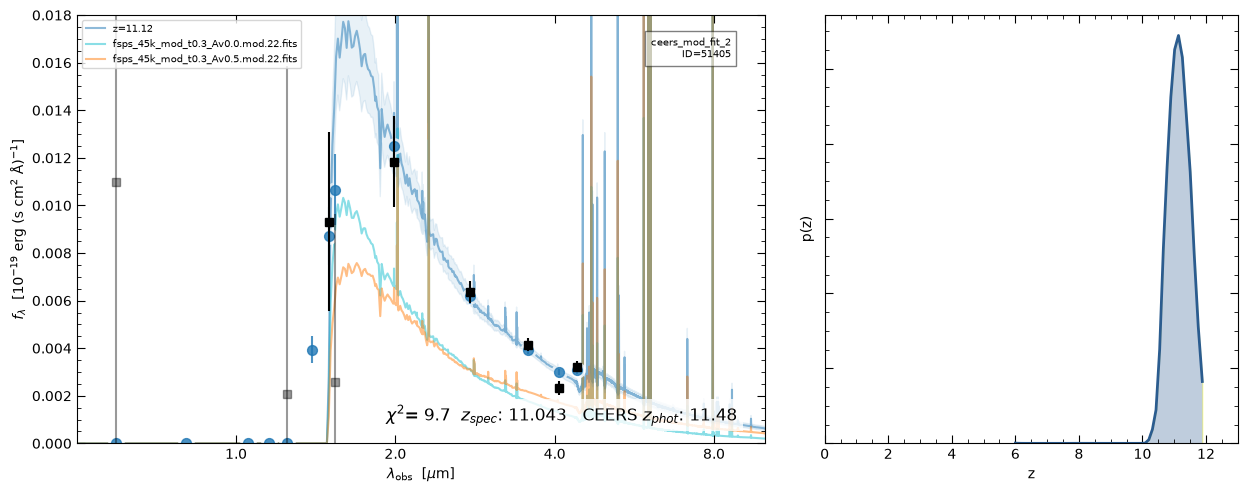

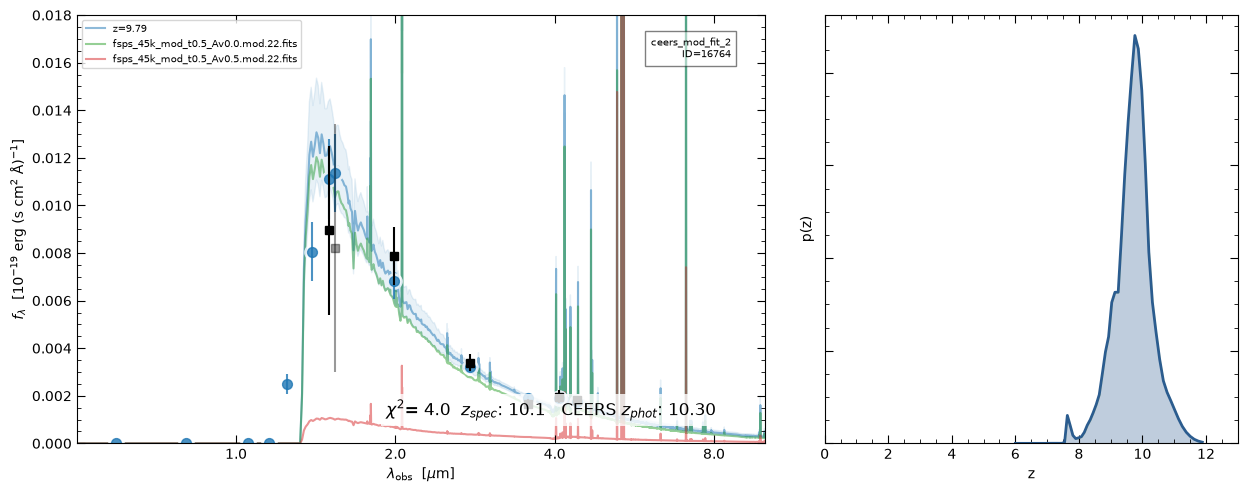

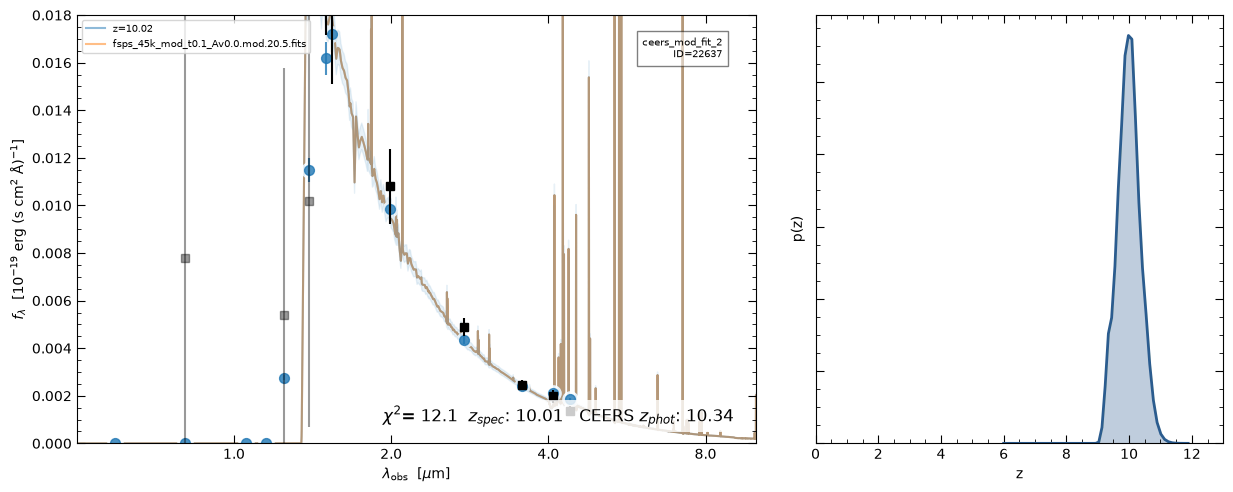

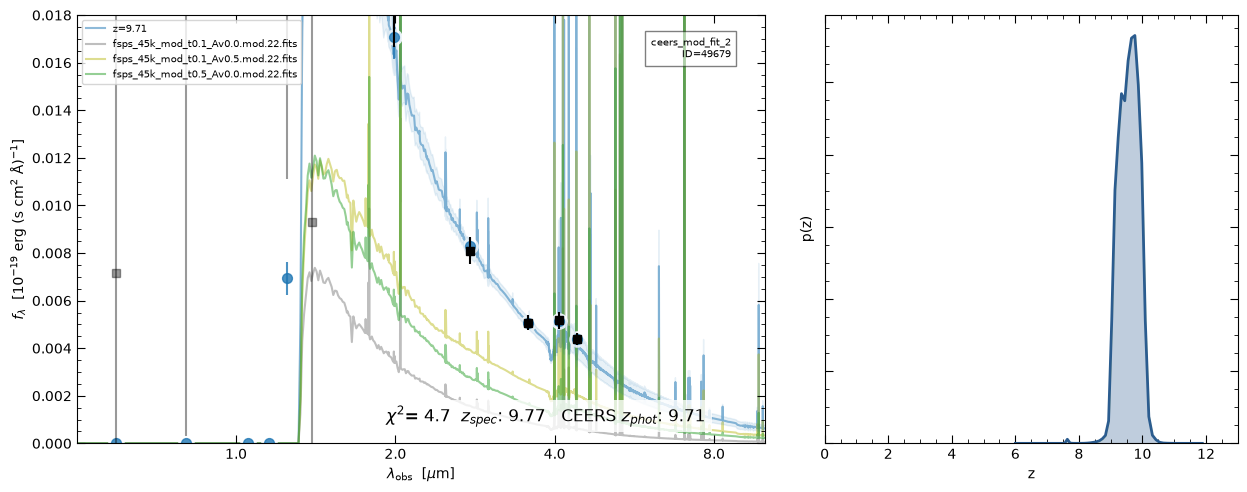

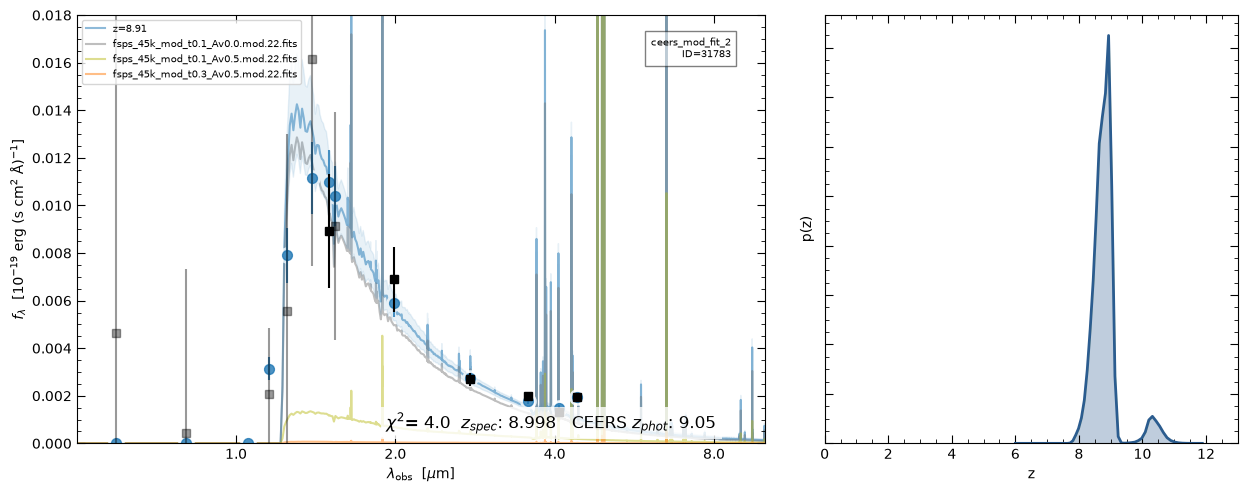

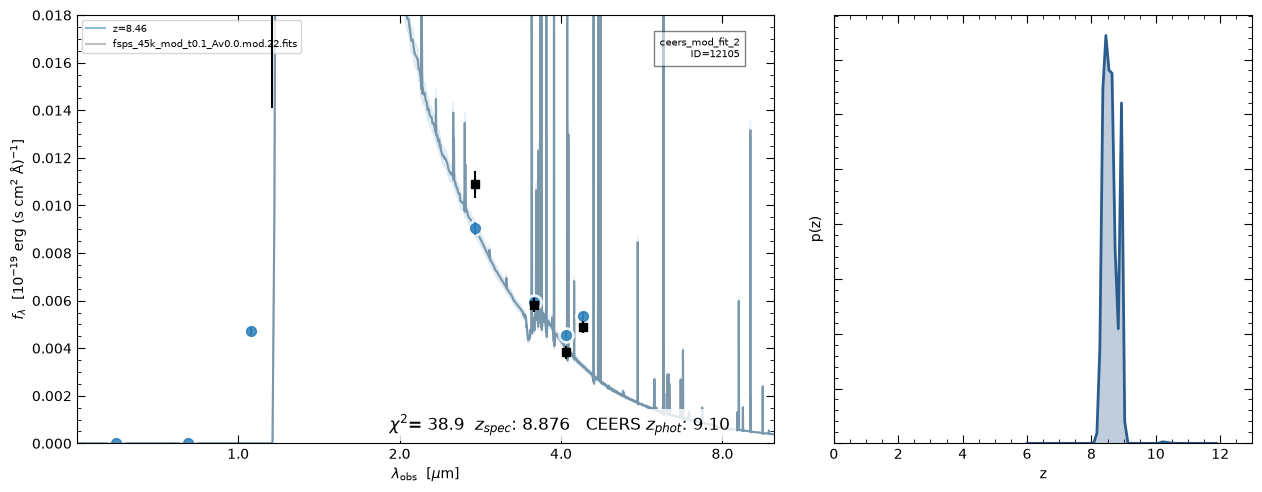

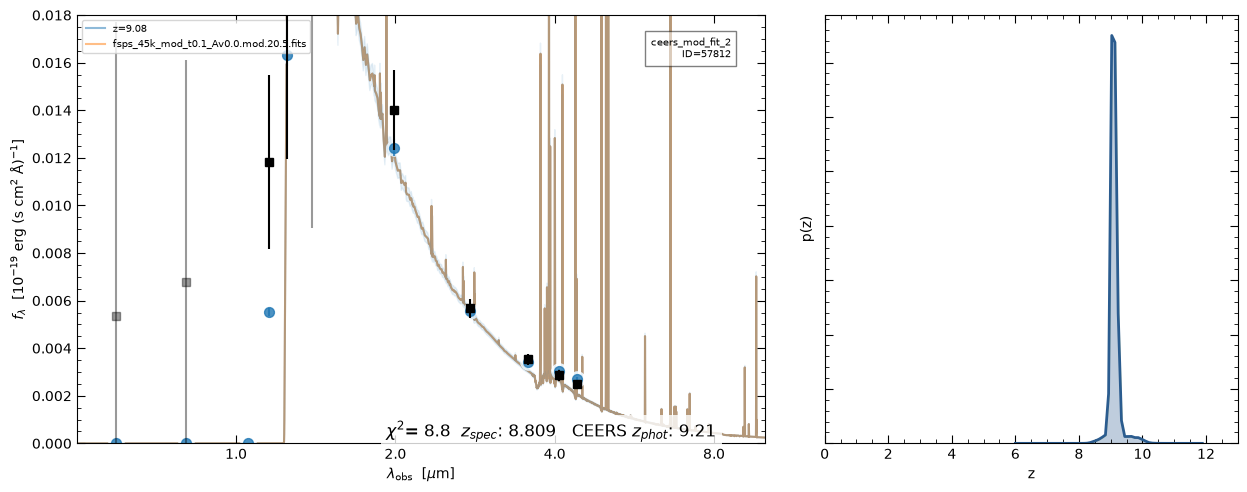

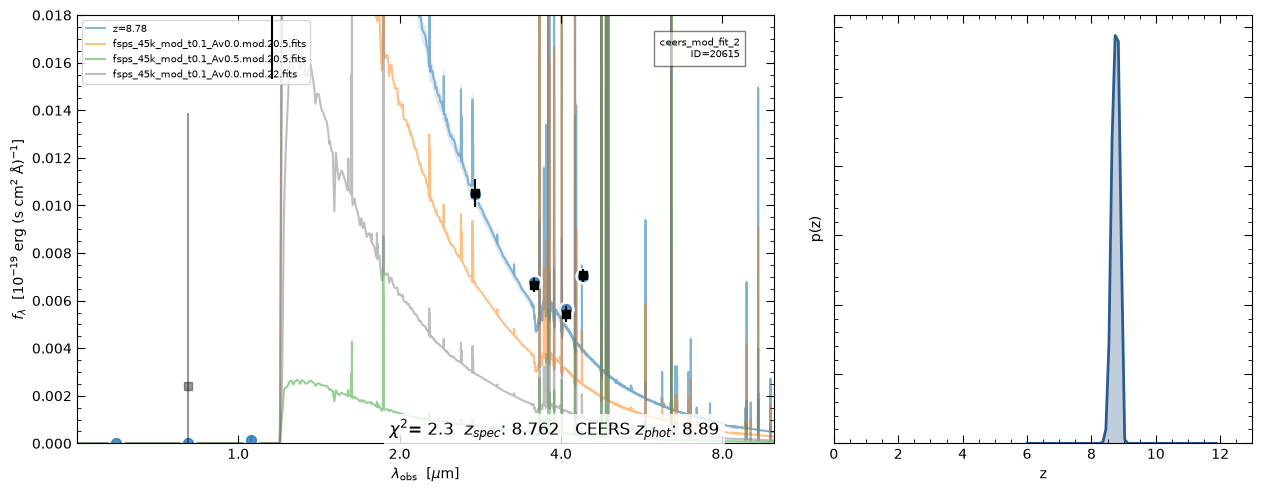

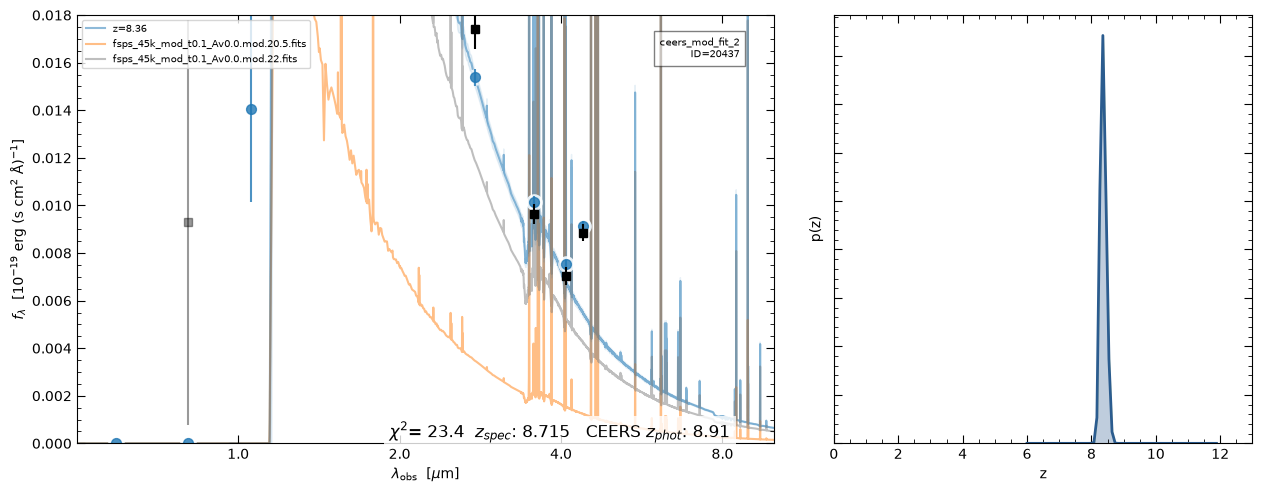

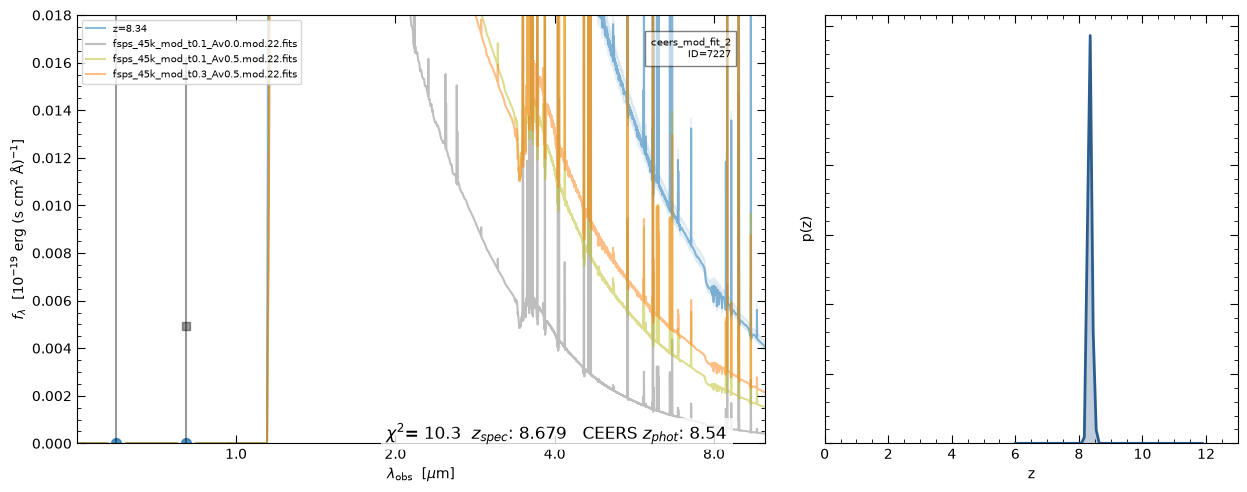

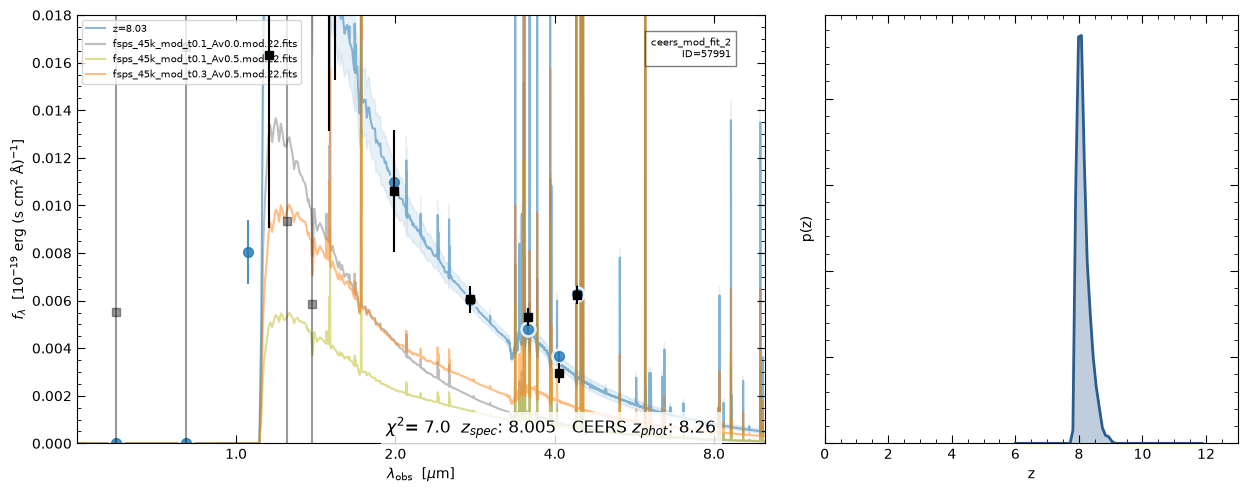

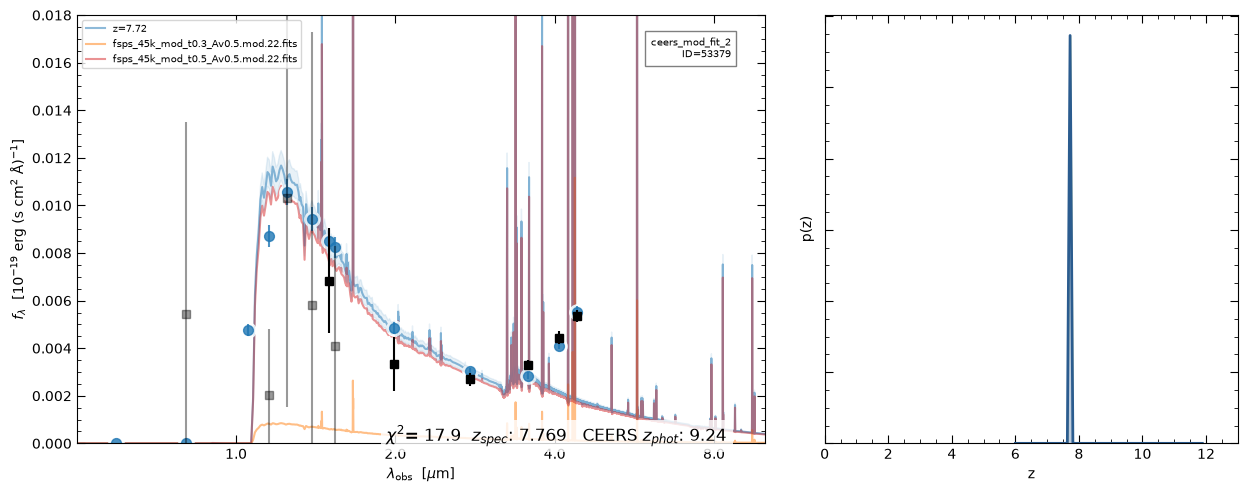

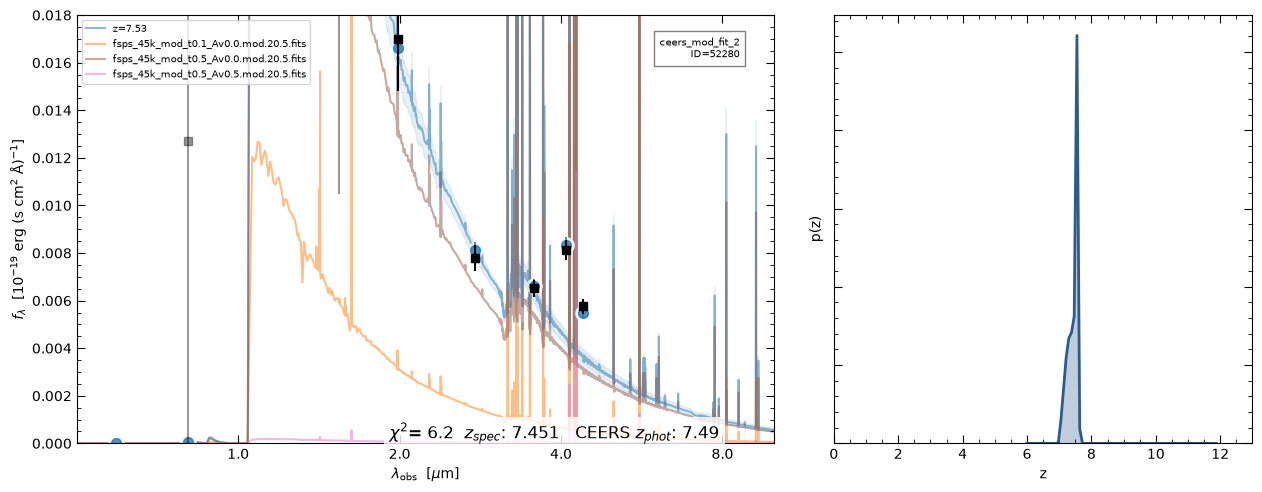

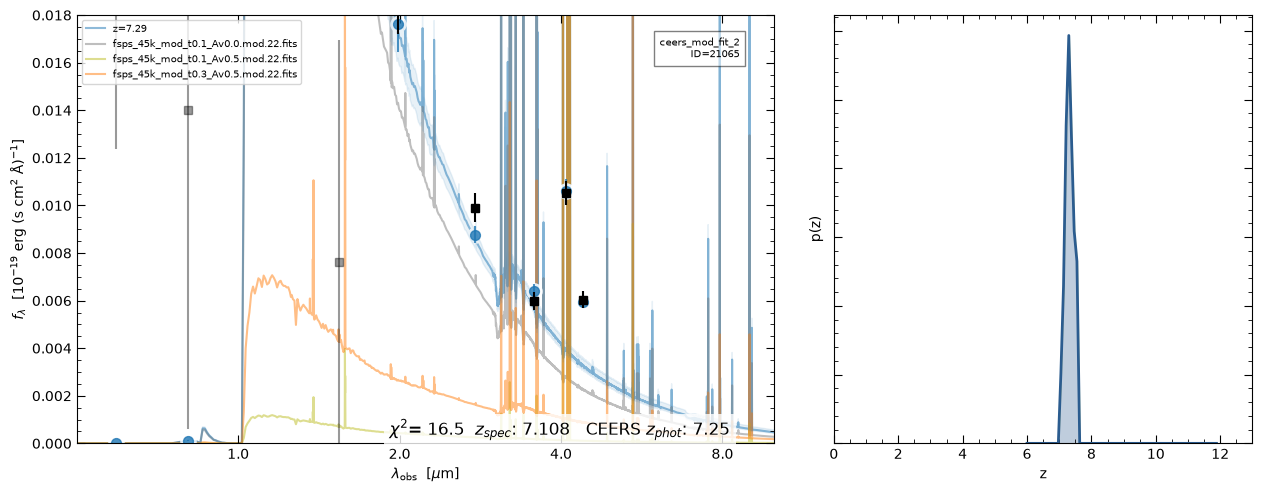

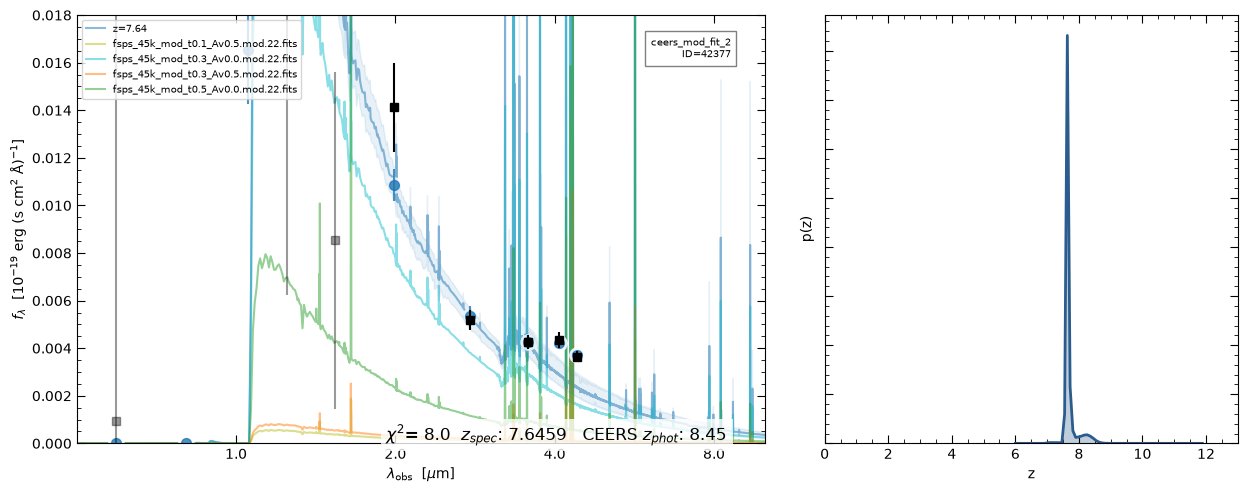

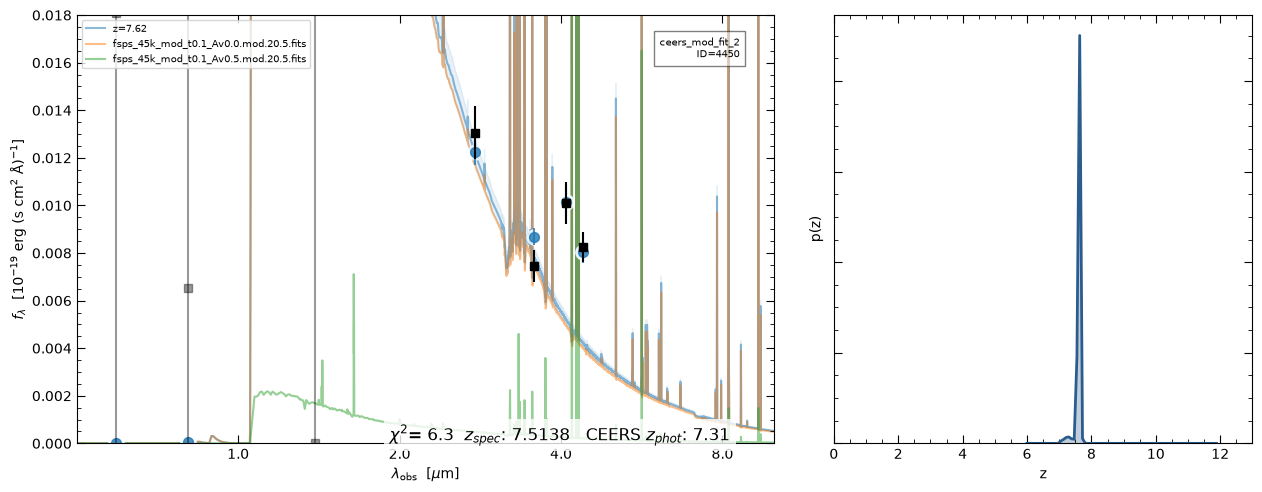

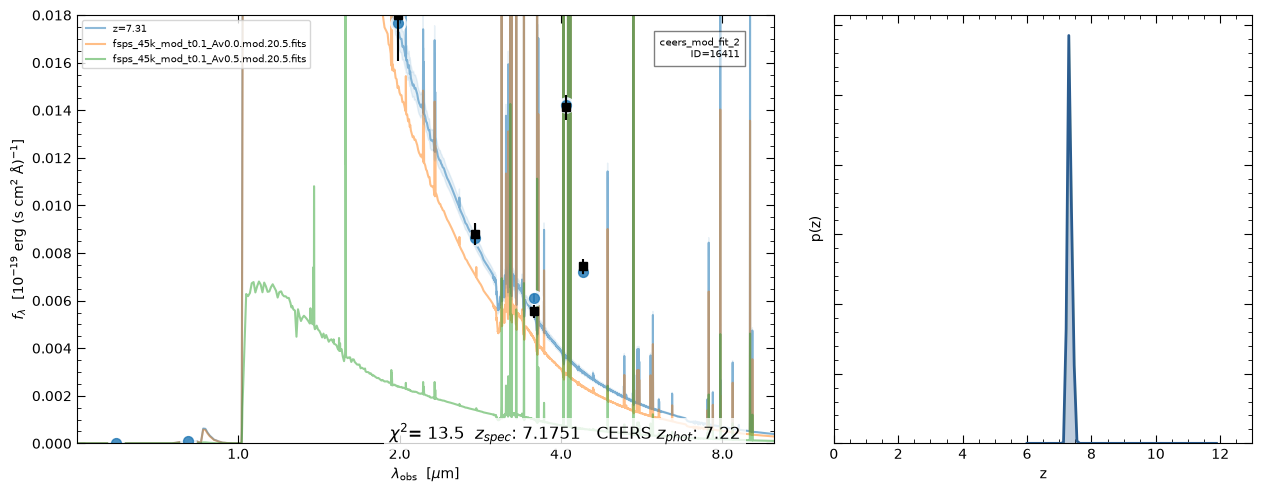

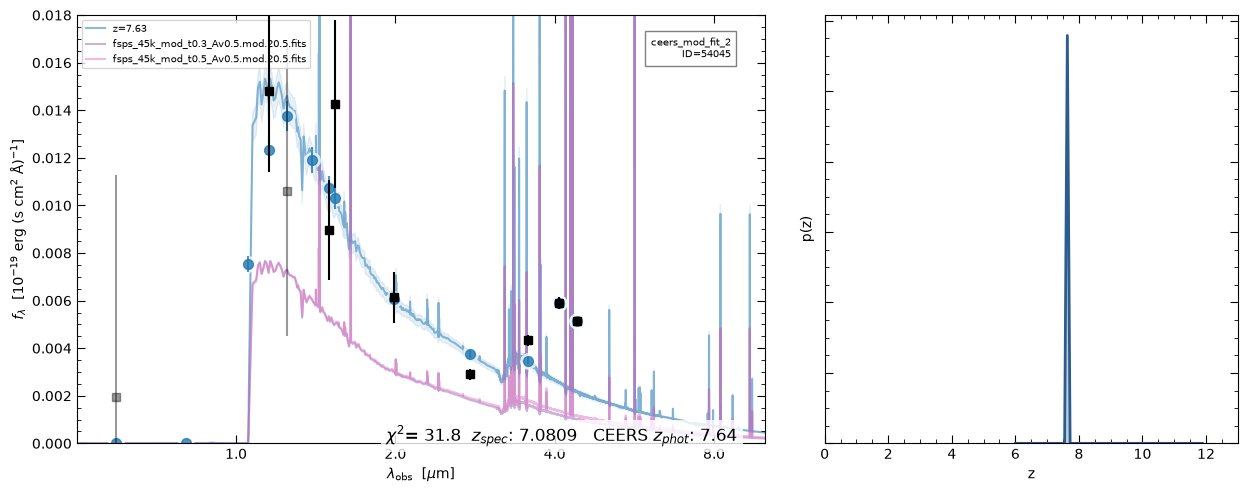

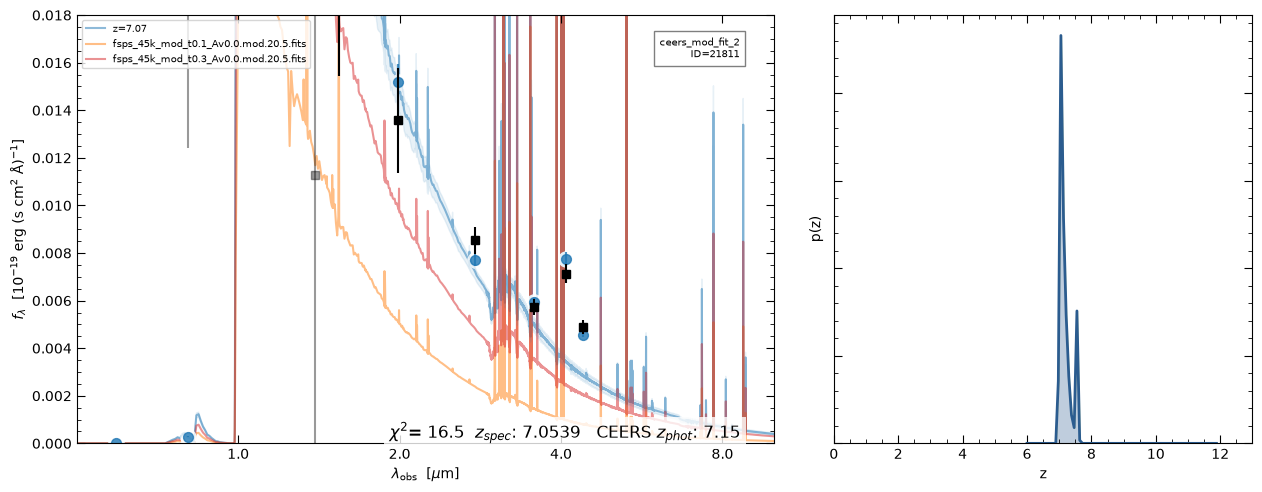

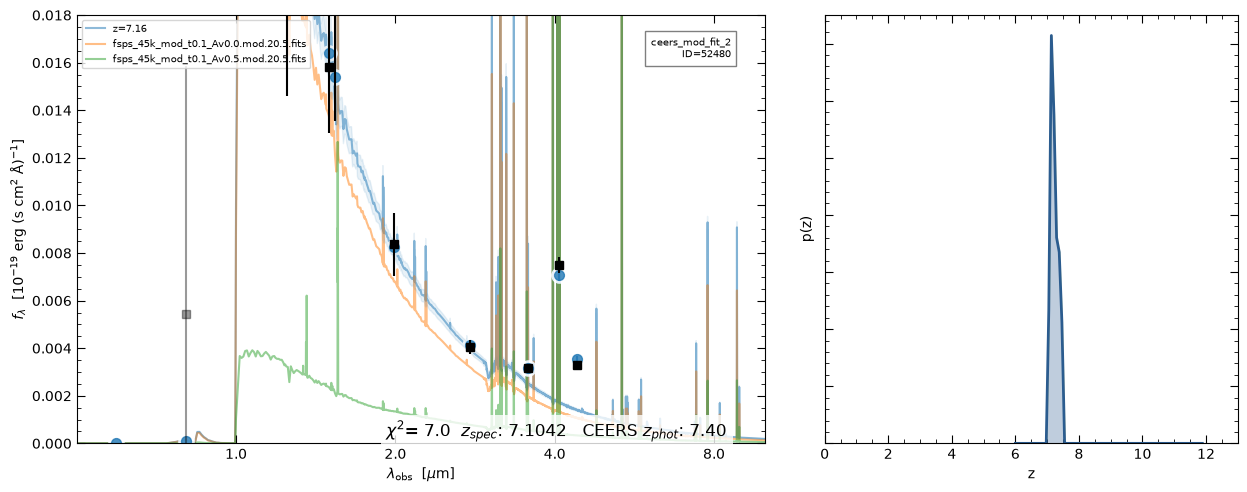

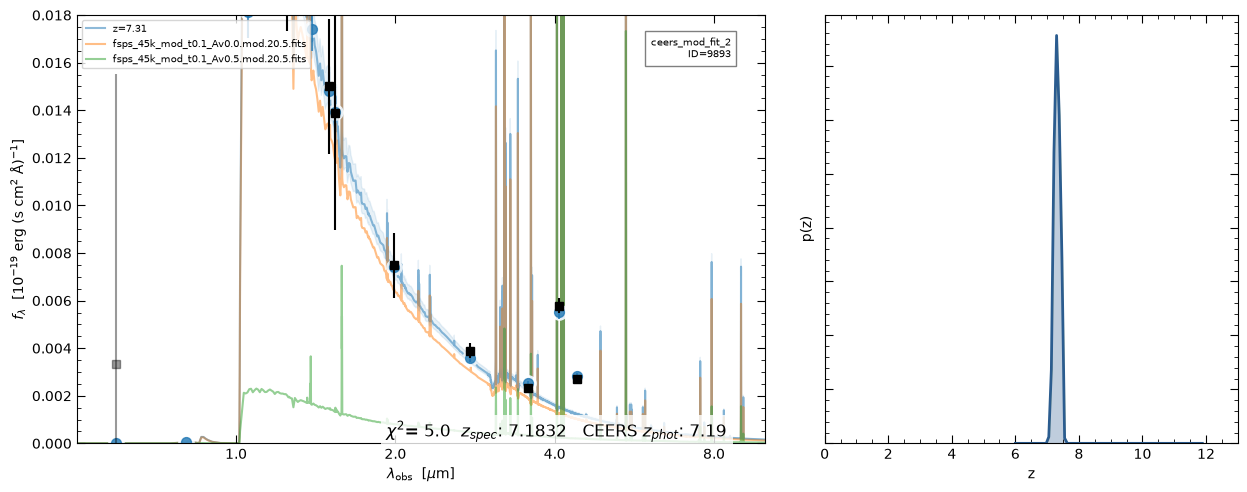

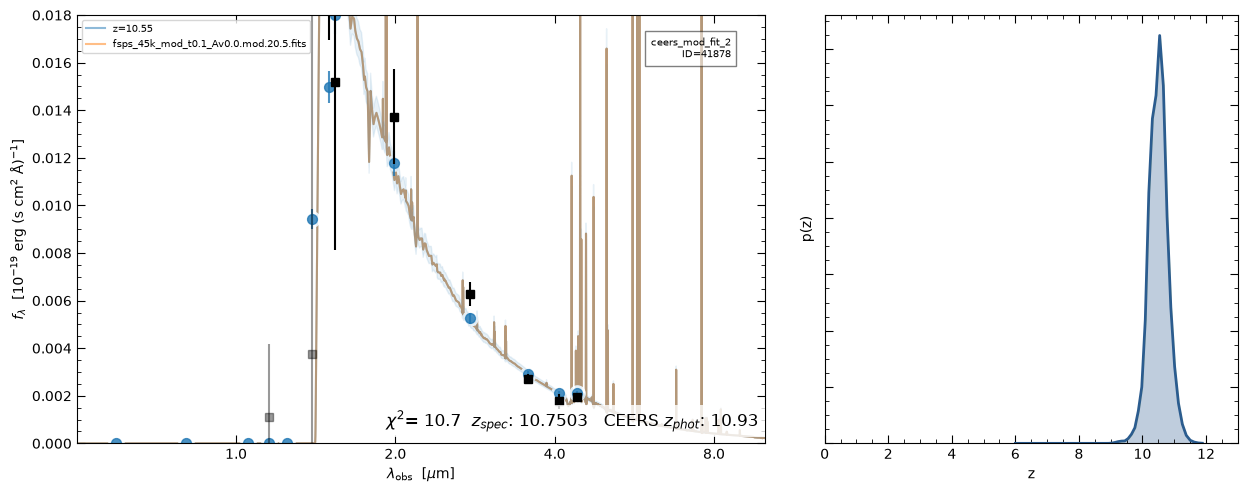

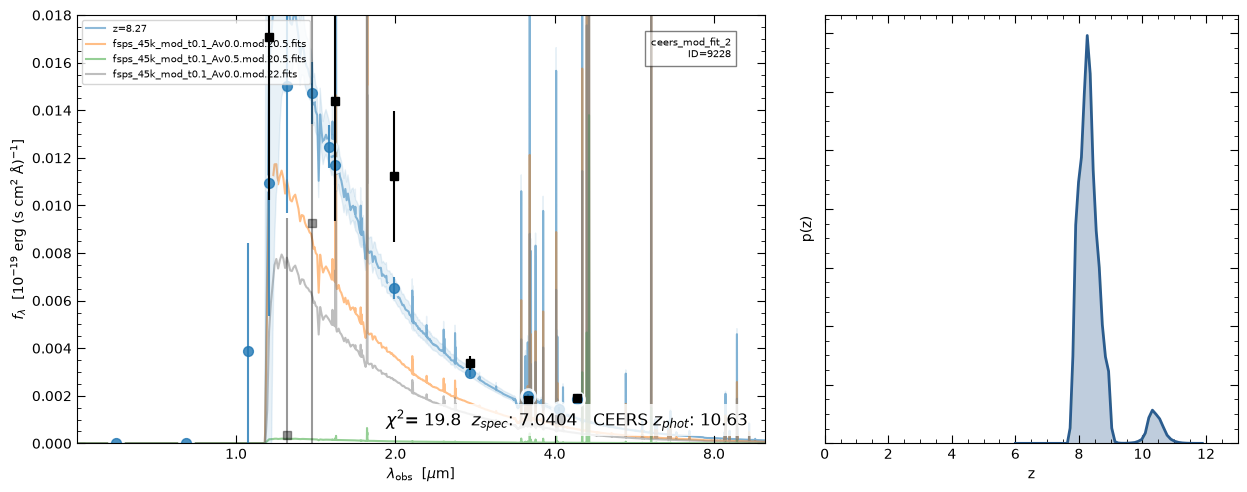

In [7]:
from matplotlib.ticker import AutoMinorLocator

ids = ez.OBJID
mask1 = zout['z_phot'] > 0
zout_masked1 = zout[mask1]
ids_masked1 = ids[mask1]

output_path = '/home/caltech-msanche3/SURF2026/scripts/ceers_mod_fit_2.zout.fits'
output_data = Table.read(output_path)
output_data_masked = output_data[mask1]

# 52480 is a little off in coords, 16224 is too
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379,52280,21065,42377,4450,16411,54045,21811,52480,9893,41878,9228]
zspec = [11.409,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.762,8.715,8.679,8.005,7.769,7.451,7.108,7.6459,7.5138,7.1751,7.0809,7.0539,7.1042,7.1832,10.7503,7.0404] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889,7.603,7.301,8.383,7.293,7.201,7.637,7.093,7.399,7.195,11.046,10.694]


ids_index = []
for i in range(len(ids)):
    n = np.where(zout['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

#print(output_data[ids_index]['id','z_phot','z_phot_chi2','mass'])

# pass ID where ids[i] was previously passed
for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[.5, 10], show_components=True,
                            logpz=False, zr=[0,13])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()

    fig.axes[0].set_ylim(0, 0.018)
    
    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zmed[i]:.2f}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 



9300
9300


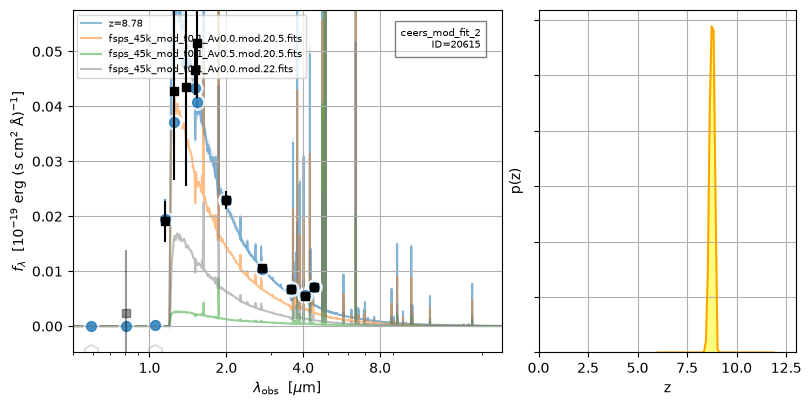

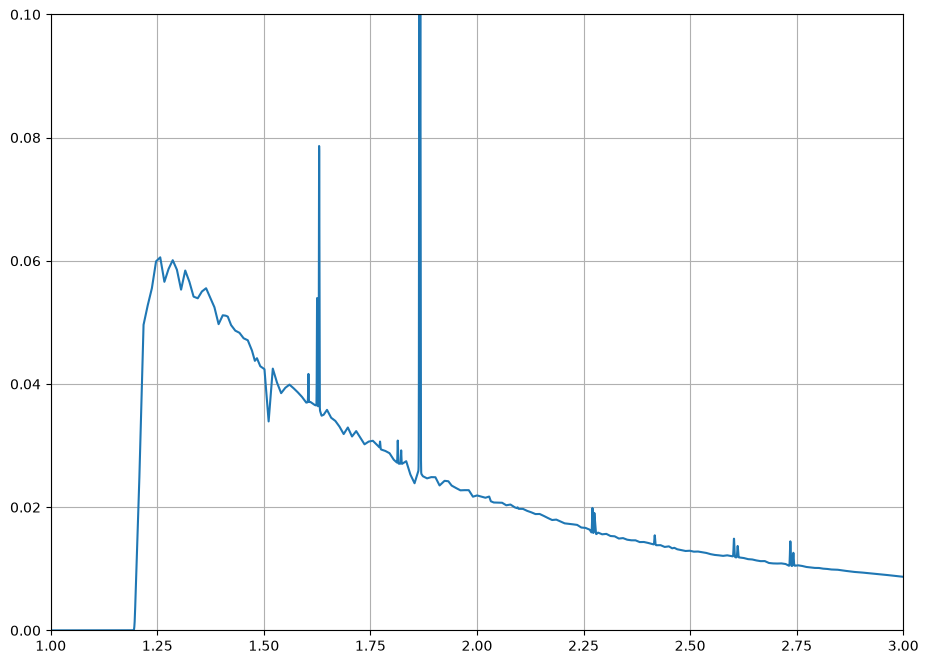

In [14]:
# Extract the best-fit spectrum dictionary for a specific object ID
fig, data = ez.show_fit(20615, xlim=[.5, 24], show_components=True,
                            logpz=False, zr=[0,13])
sed_data = ez.show_fit(id=20615, get_spec=True, show_fnu=0)

# Extract wavelength and best-fit flux density arrays
wavelengths = sed_data['templz']  # Observed frame wavelength (Angstroms)
flux_density = sed_data['templf'] # Best-fit template flux density
print(len(wavelengths))
print(len(flux_density))
fig,ax = plt.subplots(figsize=(11,8))
ax.plot(wavelengths/10000,flux_density)
ax.set_xlim(1,3)
ax.set_ylim(0.0,0.1)
ax.grid(True)

In [9]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
# 1. The redshift evaluation grid (1D array)
zgrid = ez.zgrid

# 2. Extract the log-likelihood array
# Shape is (NOBJ, NZ) where NOBJ is catalog size, NZ is length of zgrid
lnp = ez.lnp

# 3. Convert log-likelihood to likelihood probability distribution P(z)
# Shift by max(lnp) per object before exponentiating to avoid numerical underflow
p_z = np.exp(lnp - np.max(lnp, axis=1, keepdims=True))

# 4. Normalize P(z) so the integral over z equals 1
p_z_norm = p_z / np.trapezoid(p_z, zgrid, axis=1)[:, np.newaxis]

z_lo = []
z_hi = []
for i in range(24):
    #fig,ax = plt.subplots()
    #ax.plot(zgrid,p_z_norm[ids_index][i])
    #ax.grid(True)

    cdf = cumulative_trapezoid(p_z_norm[ids_index][i], zgrid, initial=0)
    # Normalize CDF strictly to 1.0 just in case
    cdf /= cdf[-1]

    # 3. Interpolate to find the z values corresponding to the target percentiles
    z_16 = np.interp(0.16, cdf, zgrid)
    z_lo.append(zout[ids_index][i]['z_phot'] - z_16)
    #z_50 = np.interp(0.50, cdf, zgrid)  # will use z_phot instead
    z_84 = np.interp(0.84, cdf, zgrid)
    z_hi.append(z_84 - zout[ids_index][i]['z_phot'])

    #print(f"Redshift 16th percentile (z_16): {z_16:.3f}")
    #print(f"Chi^2 z_phot: {zout[ids_index][i]['z_phot']:.3f}")
    #print(f"Redshift 84th percentile (z_84): {z_84:.3f}")
    #print(f"1-sigma lower/upper bounds: z = {zout[ids_index][i]['z_phot']:.3f} +{z_84 - zout[ids_index][i]['z_phot']:.3f} -{zout[ids_index][i]['z_phot'] - z_16:.3f}")
    #print()


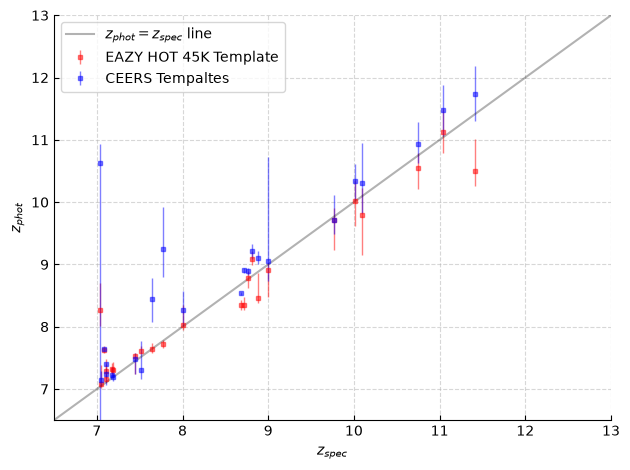

In [10]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
#find their index on the masked output table
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379,52280,21065,42377,4450,16411,54045,21811,52480,9893,41878,9228]
zspec = [11.409,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.762,8.715,8.679,8.005,7.769,7.451,7.108,7.6459,7.5138,7.1751,7.0809,7.0539,7.1042,7.1832,10.7503,7.0404] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889,7.603,7.301,8.383,7.293,7.201,7.637,7.093,7.399,7.195,11.046,10.694]
ids_index = [10334, 47933, 15751, 21441, 46299, 29946, 11167, 54216, 19472, 19299, 6397, 54393, 49864, 48782, 19909, 39233, 3696, 15399, 50523, 20633, 48980, 8984, 38753, 8324]

eazy_zphot = []
for id in ids_index:
    eazy_zphot.append(output_data[id]['z_phot'])

err = [z_lo,z_hi]

#print(eazy_zphot)

fig,ax = plt.subplots()
x = np.linspace(6.5,13,10)
y = np.linspace(6.5,13,10)
#ax.scatter(eazy_zphot,zspec,c='r',s=3)
plt.errorbar(zspec, eazy_zphot, yerr=err, fmt='s',c='r',ms=3,elinewidth=1,alpha=0.5)
#ax.scatter(zspec,ceers_zphot,c='b',s=3)
#ax.scatter(zspec,ceers_zmed,c='b',s=3)
plt.errorbar(zspec, ceers_zmed, yerr=ceers_err, fmt='s',c='b',ms=3,elinewidth=1,alpha=0.5)
ax.plot(x,y,alpha=0.3,c='k')
ax.set_ylim(6.5,13)
ax.set_xlim(6.5,13)
ax.set_xlabel(r'$z_{spec}$')
ax.set_ylabel(r'$z_{phot}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend([r'$z_{phot} = z_{spec}$ line',"EAZY HOT 45K Template",'CEERS Tempaltes'])
plt.tight_layout()

Average CEERS Templates z_phot absolute error: 4.805e-02
Average EAZY HOT 45K Templates z_phot absolute error: 2.497e-02


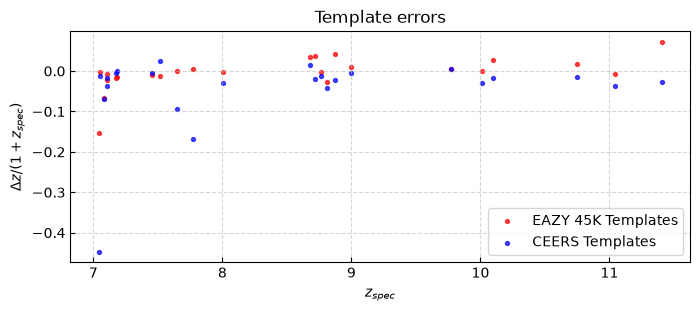

In [11]:
ceers_err = []
eazy_err = []

for i in range(len(zspec)):
    #ceers_err.append((zspec[i]-ceers_zphot[i])/(1+zspec[i]))
    ceers_err.append((zspec[i]-ceers_zmed[i])/(1+zspec[i]))
    eazy_err.append((zspec[i]-eazy_zphot[i])/(1+zspec[i]))
#print(eazy_err)
#print(ceers_err)

print(f"Average CEERS Templates z_phot absolute error: {np.mean(np.abs(ceers_err)):.3e}")
print(f"Average EAZY HOT 45K Templates z_phot absolute error: {np.mean(np.abs(eazy_err)):.3e}")

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,eazy_err,alpha=0.7,c='r',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.set_title("Template errors")
ax.scatter(zspec,ceers_err,alpha=0.7,c='b',s=8)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
ax.legend(["EAZY 45K Templates","CEERS Templates"])

# the over estimation of the redshift (here shown as a negative value on the y axis) 
# proves that damped lyman alpha features may affect us here


24
0.3139050291231085


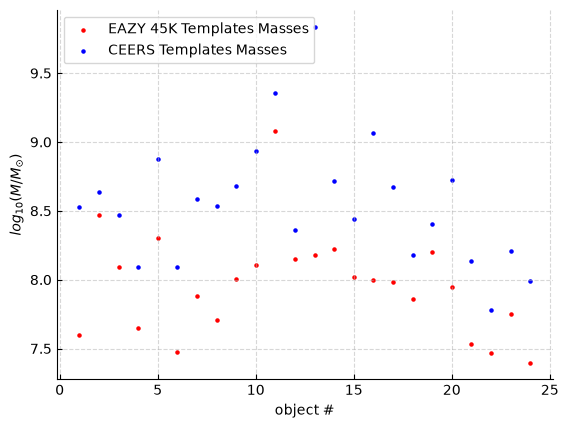

In [12]:
eazy_mass = []
ceers_mass  = []
x = np.linspace(1,24,24)
for id in ids_index:
    #print(f'eazy mass:',np.log10(output_data[id]['mass']))
    eazy_mass.append(np.log10(output_data[id]['mass']))
    #print(f'ceers mass:',ceers_data_masked[id]['LP_MASS_BEST'],"\n")
    ceers_mass.append(ceers_data[id]['LP_MASS_BEST'])
print(len(eazy_mass))
fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='r',s=5)
ax.scatter(x,ceers_mass,c='b',s=5)
ax.set_xlabel('object #')
ax.set_ylabel(r'$log_{10}(M/M_{\odot})$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY 45K Templates Masses","CEERS Templates Masses"])

change = []
for i in range(len(eazy_mass)):
    lin_e_mass = 10**eazy_mass[i]
    lin_c_mass = 10**ceers_mass[i]
    change.append((lin_e_mass/lin_c_mass).item())

print(np.mean(change))


24
8012586.4210737115


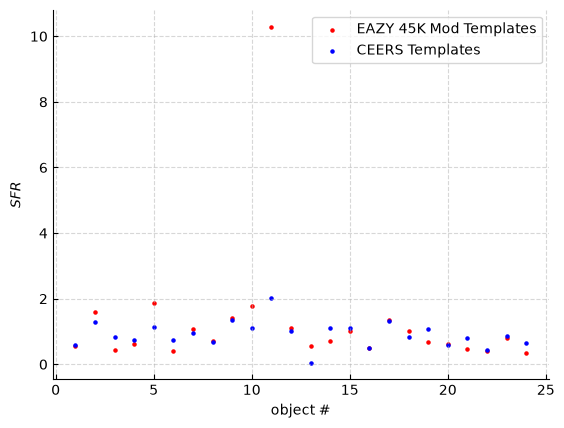

In [22]:
eazy_mass = []
ceers_mass  = []
x = np.linspace(1,24,24)
for id in ids_index:
    #print(f'eazy mass:',np.log10(output_data[id]['mass']))
    eazy_mass.append(output_data[id]['sfr'])
    #print(f'ceers mass:',ceers_data_masked[id]['LP_MASS_BEST'],"\n")
    ceers_mass.append(ceers_data[id]['LP_SFR_BEST'])
print(len(eazy_mass))
fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='r',s=5)
ax.scatter(x,ceers_mass,c='b',s=5)
ax.set_xlabel('object #')
ax.set_ylabel(r'$SFR$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY 45K Mod Templates","CEERS Templates"])

change = []
for i in range(len(eazy_mass)):
    lin_e_mass = 10**eazy_mass[i]
    lin_c_mass = 10**ceers_mass[i]
    change.append((lin_e_mass/lin_c_mass).item())

print(np.mean(change))
